<a href="https://colab.research.google.com/github/tripathiosho/ImportantNotebooks/blob/main/Pytorch_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU" -O healthyfime.csv
df = pd.read_csv("healthyfime.csv")
df.head()

--2026-09-29 01:55:55--  https://drive.google.com/uc?export=download&id=1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU
Resolving drive.google.com (drive.google.com)... 173.194.210.102, 173.194.210.138, 173.194.210.113, ...
Connecting to drive.google.com (drive.google.com)|173.194.210.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU&export=download [following]
--2026-09-29 01:55:55--  https://drive.usercontent.google.com/download?id=1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.134.132, 2607:f8b0:400c:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.134.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 761835 (744K) [application/octet-stream]
Saving to: ‘healthyfime.csv’

healthyfime.csv     100%[===================>] 743.98K  --.-

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [ ]:
df['gender'].value_counts()

,count
gender,
M,8467
F,4926


In [ ]:
df.replace({"M": 0, "F": 1}, inplace=True)
df.head()

/tmp/ipykernel_3328/3197794122.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"M": 0, "F": 1}, inplace=True)


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
classes = list(df['class'].unique())
mapping_dict = {ch: i for i, ch in enumerate(sorted(classes, reverse=True))}
print(mapping_dict)
df['class'].replace(mapping_dict, inplace=True)
df.head()

{'D': 0, 'C': 1, 'B': 2, 'A': 3}


/tmp/ipykernel_3328/2550660351.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['class'].replace(mapping_dict, inplace=True)
/tmp/ipykernel_3328/2550660351.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'].replace(mapping_dict, inplace=True)


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,1
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,3
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,1
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,2
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,2


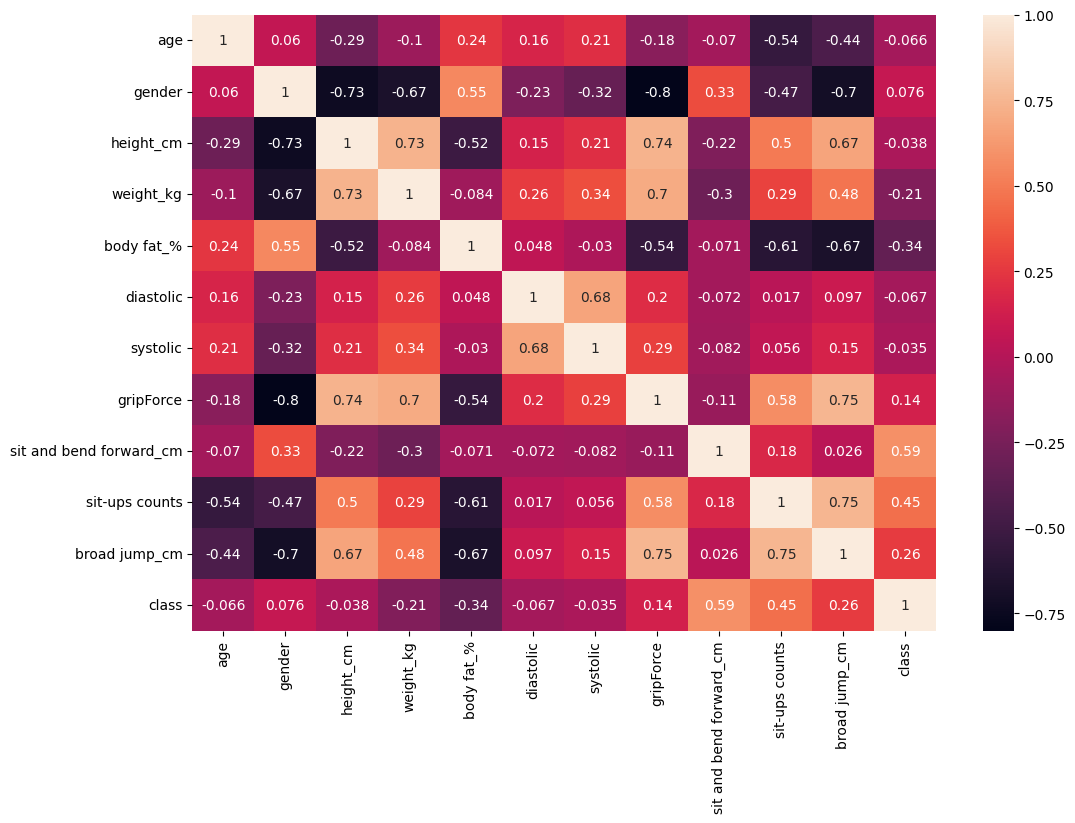

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True)
plt.show()

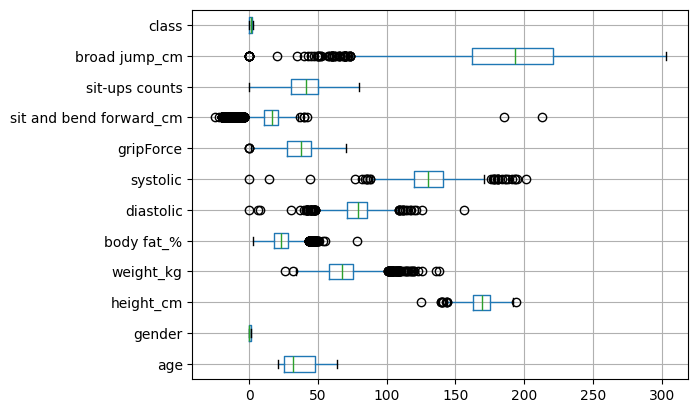

In [ ]:
df.boxplot(rot=0, vert=False)
plt.show()


In [ ]:
X, y = df.iloc[:, :-1], df.iloc[:, -1]
print(X.shape, y.shape)


(13393, 11) (13393,)


In [ ]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.1, random_state=42)

print('Train : ', X_train.shape, y_train.shape)
print('Valid : ', X_val.shape, y_val.shape)
print('Test  : ', X_test.shape, y_test.shape)

Train :  (10847, 11) (10847,)
Valid :  (1206, 11) (1206,)
Test  :  (1340, 11) (1340,)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
###############
import torch

x = torch.tensor([
    [25.0, 70.0],
    [30.0, 80.0]
])


In [ ]:
x.shape

torch.Size([2, 2])

In [ ]:
x = torch.tensor(3.0, requires_grad=True) #### tell pytorch to track the operations so it can caluclate derivatives later
y = x ** 2

y.backward() ##### compute the gradient

print(x.item())
print(y.item())
print(x.grad.item()) #derivative of y wrt x

3.0
9.0
6.0


In [ ]:
#################

w= torch.tensor(1.0, requires_grad=True)
optimizer= torch.optim.SGD([w], lr=0.1)

In [ ]:
prediction = 2 * w
loss= (prediction - 6)**2

In [ ]:
loss.backward()

In [ ]:
w.item() #w old

1.0

In [ ]:
w.grad.item()

-16.0

In [ ]:
optimizer.step()

In [ ]:
w.item()

2.5999999046325684

In [ ]:
####################

import torch.nn as nn

In [ ]:
X_train.shape

(10847, 11)

In [ ]:
layer= nn.Linear(in_features=11, out_features = 64)

In [ ]:
model= nn.Sequential(
        nn.Linear(11,64),
        nn.ReLU(),
        nn.Linear(64,4)

        )

In [ ]:
print(model)

Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=4, bias=True)
)


In [ ]:
sum(i.numel() for i in model.parameters())

1028

In [ ]:
for name,param in model.named_parameters():
  print(name,tuple(param.shape))

0.weight (64, 11)
0.bias (64,)
2.weight (4, 64)
2.bias (4,)


In [ ]:
#optional

def initialize_weights(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            nn.init.kaiming_uniform_(param, nonlinearity='relu')
        elif 'bias' in name:
            nn.init.constant_(param, 0)

print("Parameters before initialization:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

initialize_weights(model)

print("\nParameters after initialization:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

In [ ]:
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything()

model = nn.Sequential(
    nn.Linear(11, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 4)
    nn.Sigmoid()
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 500
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # end-of-epoch bookkeeping — this is where "history" comes from
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train_t)
        train_loss = criterion(train_preds, y_train_t).item()
        train_acc = (train_preds.argmax(1) == y_train_t).float().mean().item()

        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_acc = (val_preds.argmax(1) == y_val_t).float().mean().item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

Epoch 000 - loss: 1.2461 - acc: 0.4406 - val_loss: 1.2376 - val_acc: 0.4420
Epoch 050 - loss: 0.6270 - acc: 0.7441 - val_loss: 0.6131 - val_acc: 0.7546
Epoch 100 - loss: 0.5903 - acc: 0.7554 - val_loss: 0.5956 - val_acc: 0.7612
Epoch 150 - loss: 0.5733 - acc: 0.7651 - val_loss: 0.5885 - val_acc: 0.7496
Epoch 200 - loss: 0.5617 - acc: 0.7706 - val_loss: 0.5898 - val_acc: 0.7438
Epoch 250 - loss: 0.5528 - acc: 0.7768 - val_loss: 0.5895 - val_acc: 0.7537
Epoch 300 - loss: 0.5464 - acc: 0.7772 - val_loss: 0.5843 - val_acc: 0.7521
Epoch 350 - loss: 0.5379 - acc: 0.7818 - val_loss: 0.5847 - val_acc: 0.7496
Epoch 400 - loss: 0.5326 - acc: 0.7847 - val_loss: 0.5866 - val_acc: 0.7496
Epoch 450 - loss: 0.5279 - acc: 0.7875 - val_loss: 0.5901 - val_acc: 0.7521


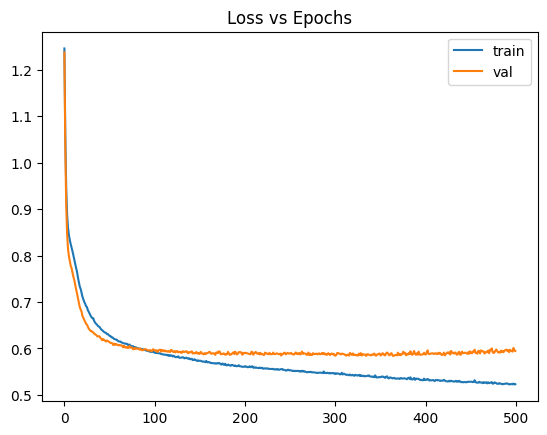

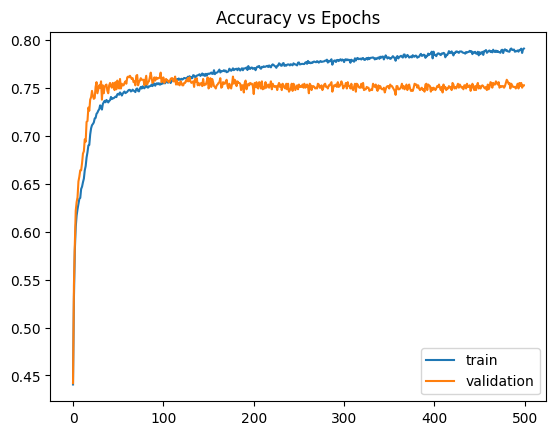

In [ ]:
epochs_range = range(n_epochs)

plt.figure()
plt.plot(epochs_range, history["train_loss"], label="train")
plt.plot(epochs_range, history["val_loss"], label="val")
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.figure()
plt.plot(epochs_range, history["train_acc"], label="train")
plt.plot(epochs_range, history["val_acc"], label="validation")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()